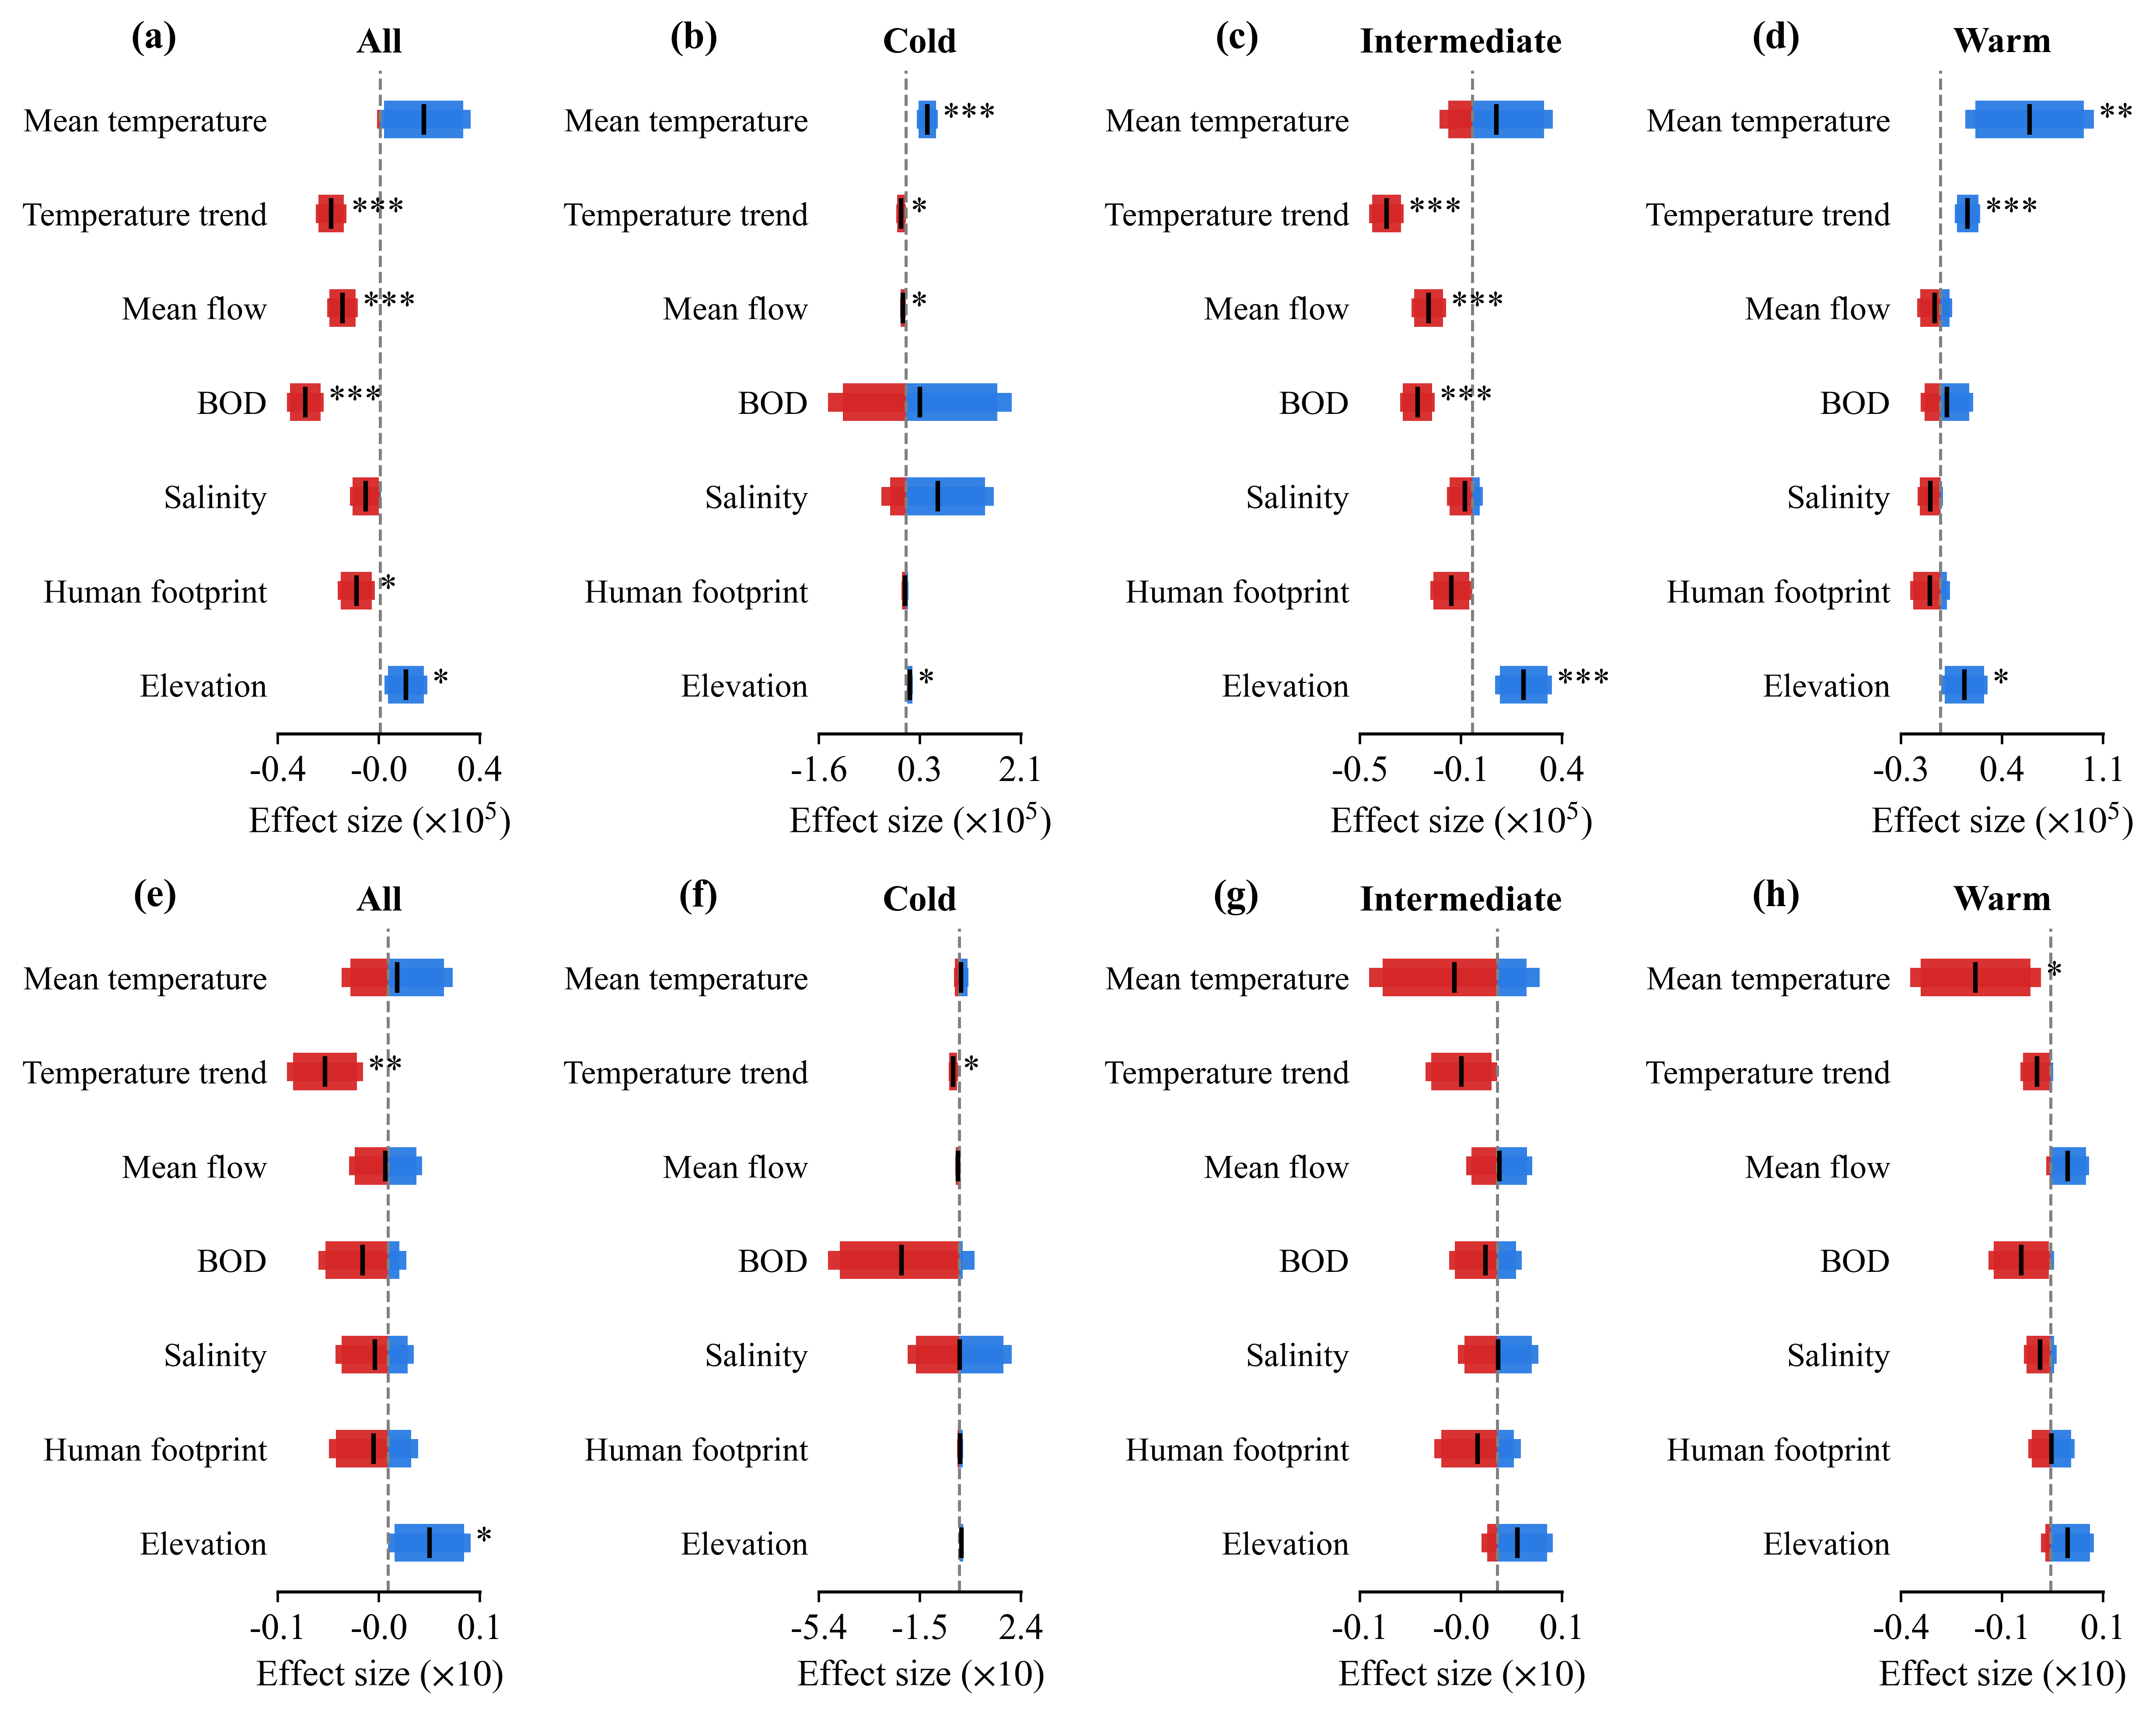

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.linewidth": 1,
    "font.size": 12
})

POS = "#2a7be4"
NEG = "#d62728"
W95 = 0.20
W80 = 0.40

order_vars = [
    "mean_temp", "slope_temp",
    "mean_flow",
    "mean_organic",
    "mean_salinity",
    "HFP_mean", "elevation"
]

name_map = {
    "mean_temp": "Mean temperature",
    "slope_temp": "Temperature trend",
    "mean_flow": "Mean flow",
    "mean_organic": "BOD",
    "mean_salinity": "Salinity",
    "HFP_mean": "Human footprint",
    "elevation": "Elevation",
}

zone_order = ["All", "Cold", "Intermediate", "Warm"]
panel_labels_top = ["(a)", "(b)", "(c)", "(d)"]
panel_labels_bottom = ["(e)", "(f)", "(g)", "(h)"]
fig = plt.figure(figsize=(10, 8), dpi=500)
gs = GridSpec(2, 4, figure=fig)

axes = [[fig.add_subplot(gs[i, j]) for j in range(4)] for i in range(2)]
def plot_zone_row(df, axes_row, panel_labels, scale, xlabel):

    # rename columns
    df = df.rename(columns={
        "CI95_L": "lo95",
        "CI95_U": "up95",
        "Effect": "coef",
        "p": "pval"
    })

    df["lo80"] = df["coef"] - (df["coef"] - df["lo95"]) * 0.8 / 0.95
    df["up80"] = df["coef"] + (df["up95"] - df["coef"]) * 0.8 / 0.95

    for c in ["coef", "lo95", "up95", "lo80", "up80"]:
        df[c] = df[c] * scale

    for i, z in enumerate(zone_order):
        ax = axes_row[i]

        sub = df[df["Zone"] == z].copy()
        sub = sub[sub["Factor"].isin(order_vars)]
        sub["Factor"] = pd.Categorical(
            sub["Factor"], categories=order_vars, ordered=True
        )
        sub = sub.sort_values("Factor")

        coef = sub["coef"].values
        lo95, up95 = sub["lo95"].values, sub["up95"].values
        lo80, up80 = sub["lo80"].values, sub["up80"].values
        pvals = sub["pval"].values

        y = np.arange(len(coef))
        labels = [name_map[v] for v in sub["Factor"]]

        # CI rectangles
        for yy, a95, b95, a80, b80, c in zip(y, lo95, up95, lo80, up80, coef):

            if a95 < 0:
                ax.add_patch(Rectangle(
                    (a95, yy - W95/2),
                    min(b95, 0) - a95, W95,
                    facecolor=NEG, linewidth=0, alpha=0.95
                ))
            if b95 > 0:
                ax.add_patch(Rectangle(
                    (max(a95, 0), yy - W95/2),
                    b95 - max(a95, 0), W95,
                    facecolor=POS, linewidth=0, alpha=0.95
                ))

            if a80 < 0:
                ax.add_patch(Rectangle(
                    (a80, yy - W80/2),
                    min(b80, 0) - a80, W80,
                    facecolor=NEG, linewidth=0, alpha=0.95
                ))
            if b80 > 0:
                ax.add_patch(Rectangle(
                    (max(a80, 0), yy - W80/2),
                    b80 - max(a80, 0), W80,
                    facecolor=POS, linewidth=0, alpha=0.95
                ))

            ax.plot(
                c, yy, "|",
                color='black',
                markersize=10,
                markeredgewidth=1.5,
                zorder=10
            )

        ax.axvline(0, color="gray", linestyle="--", linewidth=1)

        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=11)
        ax.invert_yaxis()

        ax.set_title(z, fontsize=12, fontweight="bold")
        ax.set_xlabel(xlabel, fontsize=12)

        xmin, xmax = ax.get_xlim()
        ticks = np.linspace(xmin, xmax, 3)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{t:.1f}" for t in ticks])

        offset = 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])
        for yy, ub, p in zip(y, up95, pvals):
            if p < 0.001: star = "***"
            elif p < 0.01: star = "**"
            elif p < 0.05: star = "*"
            else: star = ""
            if star:
                ax.text(
                    ub + offset, yy, star,
                    fontsize=12, va="center"
                )

        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.tick_params(axis="y", length=0)

        ax.text(
            -0.5, 1.02, panel_labels[i],
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=13, fontweight="bold"
        )


df_lcbd = pd.read_csv(
    r"D:\paper\outputdata\Modelling of uniqueness trends\LCBD_MarginalEffects_by_zone_OVERALL.csv"
)

plot_zone_row(
    df_lcbd,
    axes[0],
    panel_labels_top,
    scale=1e5,
    xlabel=r"Effect size ($\times 10^{5}$)"
)

df_fd = pd.read_csv(
    r"D:\paper\outputdata\Modelling of function diversity trends\FDis_MarginalEffects_by_zone_OVERALL.csv"
)

plot_zone_row(
    df_fd,
    axes[1],
    panel_labels_bottom,
    scale=10,
    xlabel=r"Effect size ($\times 10$)"
)
plt.tight_layout()
plt.savefig(
    r"C:\Users\Lenovo\Desktop\extendFig12.png",
    dpi=300, bbox_inches="tight"
)
plt.show()
